In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
etanol,46.069,2.3439,3.2255,216.1,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,etanol,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
etanol,H,etanol,e,2527.7,0.025587
co2,H,co2,e,0,0
etanol,H,co2,e,1263.85,0
etanol,e,co2,H,1263.85,0
"""

model = PCSAFT(["co2", "etanol"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 193.4090902230296; 193.4090902230296 216.1]
[2.785e-10 3.00525e-10; 3.00525e-10 3.2255e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 313.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 313.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 500.0,
        :guess   => 450.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 500.0, :param => :epsilon, :indices => (1, 2), :guess => 450.0, :lower => 10.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_etanol.csv")
fix_line_endings("vley_etanol.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_etanol.csv"
        "vley_etanol.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_etanol.csv
Fixed: vley_etanol.csv
Initial objective value: 1.0e100


In [6]:
method = ECA(; options = Options(iterations = 100000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([182.8786689919913], PCSAFT{BasicIdeal, Float64}("co2", "etanol"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 182.8786689919913; 182.8786689919913 216.1]
[2.785e-10 3.00525e-10; 3.00525e-10 3.2255e-10]
kij = 0.044990825049040284


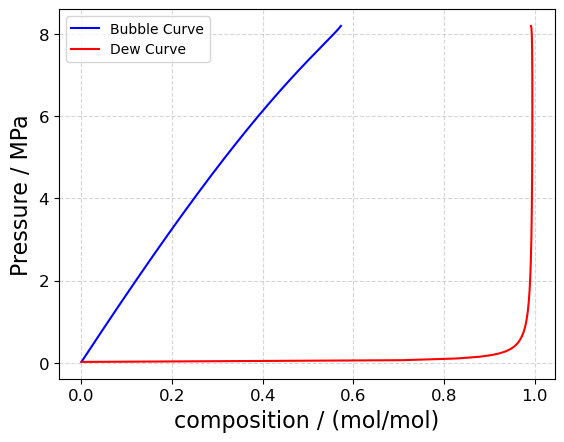

In [8]:
import PyPlot; const plt = PyPlot
using Clapeyron
"""
N = 300
T = 313.15

# 1. Menaikkan rentang batas atas X sedikit (misal ke 0.95 atau 0.98) 
# agar kurva puncak kritisnya bisa terhitung dan menutup sempurna.
x = range(1e-8, 1, length=N)

p = zeros(N)
y = zeros(N)

# Inisialisasi variabel v0 untuk menampung tebakan awal secara kontinu
v0 = []

# 2. Perulangan dengan proteksi try-catch
for j in 1:N
    try
        if j == 1
            # Iterasi pertama menggunakan tebakan default Clapeyron
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]])
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Simpan tebakan awal untuk iterasi berikutnya
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        else
            # Iterasi selanjutnya memanfaatkan nilai v0 dari titik sebelumnya
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]]; v0=v0)
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Perbarui nilai v0 dengan hasil konvergensi terbaru
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        end
    catch e
        # JIKA solver gagal konvergen di dekat titik kritis, titik tersebut 
        # akan diisi dengan NaN (Not a Number) agar kode TIDAK crash/eror,
        # dan grafik Python tetap bisa menggambar bagian yang sukses.
        p[j] = NaN
        y[j] = NaN
    end
end
"""
N    = 401
idxend = N
T    = 313.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]]; v0 = v0)
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

# 3. Bagian pembuatan grafik (Plotting)
plt.clf()
plt.plot(x, p./1e6, color="blue", label="Bubble Curve")
plt.plot(y, p./1e6, color="red", label="Dew Curve")
plt.xlabel("composition / (mol/mol)", fontsize=16)
plt.ylabel("Pressure / MPa", fontsize=16)
plt.xlim()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(true, linestyle="--", alpha=0.5) # opsional: menambahkan grid tipis agar rapi

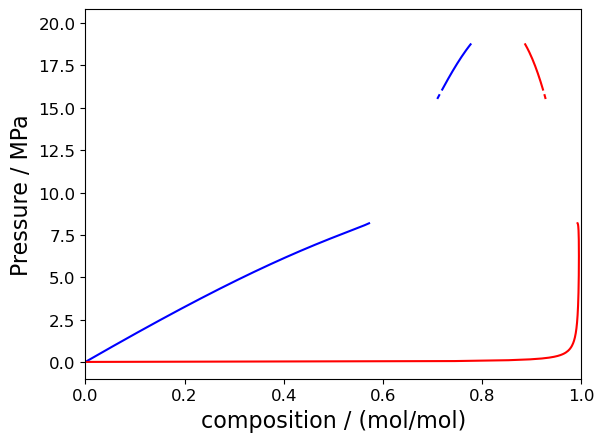

([-2.5, 0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0, 22.5], PyCall.PyObject[PyObject Text(0, -2.5, '−2.5'), PyObject Text(0, 0.0, '0.0'), PyObject Text(0, 2.5, '2.5'), PyObject Text(0, 5.0, '5.0'), PyObject Text(0, 7.5, '7.5'), PyObject Text(0, 10.0, '10.0'), PyObject Text(0, 12.5, '12.5'), PyObject Text(0, 15.0, '15.0'), PyObject Text(0, 17.5, '17.5'), PyObject Text(0, 20.0, '20.0'), PyObject Text(0, 22.5, '22.5')])

In [9]:
import PyPlot; const plt = PyPlot

N    = 300
T    = 313.15

x    = LinRange(0., 0.9,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [10]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [11]:
aard_p   = calculate_AAD(model_opt, "vlep_etanol.csv", vle_p)


=== AAD: vlep_etanol.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.0280      530000.000000  485882.522758  8.3241  
0.0648      1140000.000000  1095913.609718  3.8672  
0.1303      2320000.000000  2161559.590085  6.8293  
0.1943      3300000.000000  3172619.469828  3.8600  
0.2731      4430000.000000  4366348.518736  1.4368  
0.4062      5850000.000000  6215736.130876  6.2519  
0.4757      6660000.000000  7078710.887307  6.2870  
0.5595      7180000.000000  8039007.130749  11.9639 
AARD = 6.1025%


6.102523646785897

In [12]:
aard_p   = calculate_AAD(model_opt, "vley_etanol.csv", vle_y)


=== AAD: vley_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.0280      0.978600      0.963272      1.5663  
0.0648      0.982500      0.982983      0.0491  
0.1303      0.986300      0.990634      0.4394  
0.1943      0.988700      0.993046      0.4395  
0.2731      0.991700      0.994328      0.2650  
0.4062      0.992300      0.994968      0.2689  
0.4757      0.990700      0.994819      0.4158  
0.5595      0.989600      0.993564      0.4005  
AARD = 0.4806%


0.480562311404748